# **ML Workflow**

## **ML Part**

1. Problem Statement
2. Data Gathering (using any method as below)
	- Webscraping
	- Extract from API
	- Extract from Dbs
	- Provided by stake holders
3. Data Assesment
	- Explore data using pandas method to get a glimpse of data
	- Identify & make a note of all the issues which needs to be cleaned
4. Data Cleaning
	- Perform cleaning
5. EDA
	- Perform EDA (uni, bi & multi)
	- Understand target column relation with all the cols
	- Identify if new features to be created
6. Data Transformation & Feature Engineering
	- Perform data transformation & feature engineering as understood in EDA
7. EDA & Hypothesis Testing
	- Perform another round of EDA after feature engieering
	- Perform hypothesis testings
8. Experiments
	- Base Model
	- Multi Model to find best model
	- HP Tuning
9. Create DVC Pipeline
	- Data Cleaning
	- Data PreProcessing
	- Data Transformation
	- Model Trainer
	- Model Evaluation
		- Log the model, regressor & transformed in mlflow
		- extract and save model path, run id in **run_information.json**
	- Model Registry
		- Add dvc remote s3: dvc remote add -d myremote **your_bucket_name**
		- dvc status
		- dvc push
		- Push model to model registry in Staging stage
		- model registry tracks the version & stages of model

10. Create FastAPI around the model
	- pydantic model for data validation & type conversion where possible
	- Uvicorn server which is faster then flask, we will get faster prediction
	- Perform sample tests/predictions on swagger UI locally

		```{
		"ID": "0x1",
		"Delivery_person_ID": "BANGRES11DEL01",
		"Delivery_person_Age": "30",
		"Delivery_person_Ratings": "4.8",
		"Restaurant_latitude": 12.9716,
		"Restaurant_longitude": 77.5946,
		"Delivery_location_latitude": 12.9352,
		"Delivery_location_longitude": 77.6245,
		"Order_Date": "2022-03-15",
		"Time_Orderd": "11:30",
		"Time_Order_picked": "11:45",
		"Weatherconditions": "Sunny",
		"Road_traffic_density": "High",
		"Vehicle_condition": 2,
		"Type_of_order": "Meal",
		"Type_of_vehicle": "motorcycle",
		"multiple_deliveries": "1",
		"Festival": "No",
		"City": "Metropolitian"
		}```

## **Ops part**

- **CI Pipeline**

**What to execute in CI/CD Pipeline**

- Pull data from DVC & Run DVC: `dvc pull` & `dvc repro`
- Execute performance tests on staged model against predefined thresholds (RMSE, R², MAE) and validate success criteria.
- If performance test succeeds, promote model from "Staging" to "Production" stage in MLflow Model Registry with performance metadata.
- If above tests pass, build Docker image, run Docker container and test the production model through API endpoints.
- Test production model via API endpoints (`/health`, `/predict`, `/docs`) for request/response validation, edge cases, and response time (<500ms) in Docker.
- Once all tests pass, push Docker image to ECR Repo.
- **Once Docker image is in ECR repo, we can deploy via CI/CD on:**
    1. EC2 using CodeDeploy (Configure ASG, Loadbalancer & Deployment method manually)
    2. ECS (Elastic Kubernetes service)
    3. EKS (Elastic Kubernetes service)

    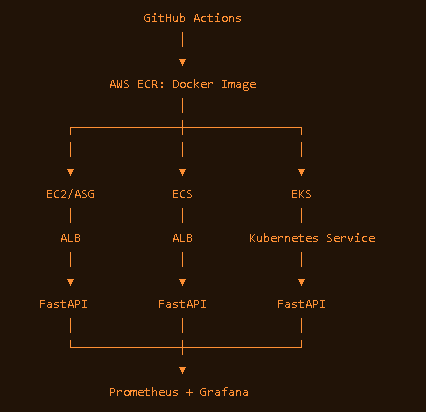

- Integrate Monitoring using ****Prometheus & Grafana****
- Integrate retraining using ****Airflow****

### 1. EC2 + ASG + LoadBalancer + CodeDeploy

1. **Define IAM roles**
    + **Launch Template**
    - roles > create role > ec2 service
    - AmazonEC2ContainerRegistryReadOnly
    - AmazonS3ReadOnlyAccess
    - AmazonEC2RoleforAWSCodeDeploy
    - **delivery_time_prediction_ec2_launchtemplate_role**

    + **CodeDeploy**
    - roles > create role > codedeploy
    - AWSCodeDeployRole (Pre Selected)
    - **delivery_time_prediction_codedeploy_role**

2. **Create launch template**
    - EC2 > launch templates > Create launch template
    - name: delivery-time-pred-template
    - version: version 1
    - check auto scaling guidance
    - quick start:
        - os: ubuntu
        - instance type: t2 micro
        - EBS Volume: 20gb
        - key_pair: ec2-docker-key
        - security group: select default
        - Advanced details > IAM instance profile > select: delivery_time_prediction_ec2_launchtemplate_role
        - paste user data script at the end (with code to add additional 2gb swap memmory)
        - create launch template

3. **Create Auto Scaling group**
    - click on *Create Auto Scaling group*
    - name: delivery_time_prediction_asg
    - create 2 availability zones
    - Attach to a new load balancer > application load balancer > delivery-time-prediction-alb > internet facing
    - under listenders > create target group > delivery-time-prediction-tg
    - health checks: Turn on Elastic Load Balancing health checks
    - mention desired capacity as per requirements
    - select as per requirement: Target tracking scaling policy
    - Enable group metrics collection within CloudWatch
    - create auto scaling group
    - **wait for sometime if it says fail, It may take 2-3 mins**
    - check if agent is running on instance or not: sudo systemctl status codedeploy-agent

    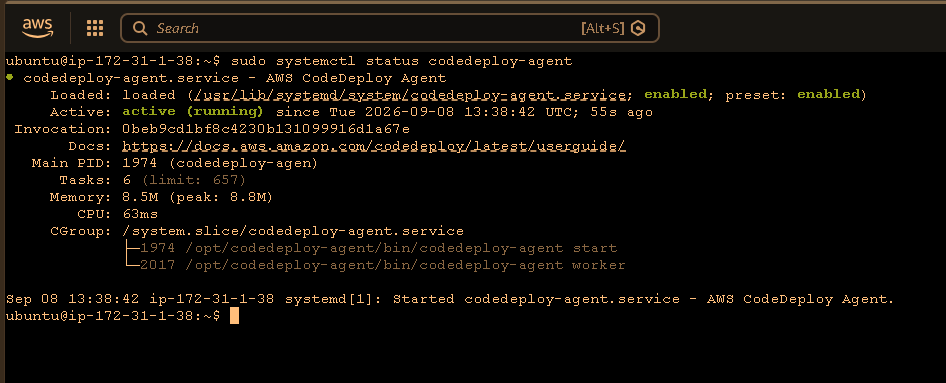

4. **Create CodeDeploy application**
    - CodeDeploy > Applications > create applications
    - name: deliverytimepredictionapp
    - compute platform: EC2/On-premises


5. **Create deployment group**
    - deployment group will be the auto scaling group
    - name: deliverytimepredictiondeploymentgroup
    - service role: delivery_time_prediction_codedeploy_role
    - deployment type:
        1. **In-place:** Updates the existing EC2 instances by stopping/replacing the current application version with the new version.
        2. **Blue/Green:** Deploys the new version to new EC2 instances, tests it, and then shifts traffic from the old environment to the new one. 
    - environment config: aws ec2 asg > select the one which we created above
    - deployment configuration: select as per requirement
    - select load balancer target group which we created above
    - create deployment group


6. create appspec.yaml file
    ```
    version: 0.0
    os: linux

    files:
    - source: /
        destination: /home/ubuntu/app

    hooks:
    BeforeInstall:
        - location: deploy/scripts/install_dependencies.sh
        timeout: 300
        runas: ubuntu

    ApplicationStart:
        - location: deploy/scripts/start_docker.sh
        timeout: 300
        runas: ubuntu
    ```


7. Create 2 files under deploy/scripts
    - install_dependencies.sh
    - start_docker.sh


8. Update CICD file to add deployment steps
    ```
      # # Zip the required files
      # - name: Zip files for deployment
      #   if: success()
      #   run: |
      #       zip -r deployment.zip appspec.yml deploy/scripts/install_dependencies.sh deploy/scripts/start_docker.sh


      # # Upload the ZIP file to S3
      # - name: Upload ZIP to S3
      #   if: success()
      #   run: |
      #       aws s3 cp deployment.zip s3://deliverytimepredictiondeployment/deployment.zip

            
      # # Deploy to AWS CodeDeploy using the uploaded ZIP file
      # - name: Deploy to AWS CodeDeploy
      #   if: success()
      #   run: |
      #       aws configure set DAGSHUB_USERNAME ${{ secrets.DAGSHUB_USERNAME }}
      #       aws configure set DAGSHUB_TOKEN  ${{ secrets.DAGSHUB_TOKEN  }}
      #       aws deploy create-deployment \
      #       --application-name deliverytimeprediction \
      #       --deployment-config-name CodeDeployDefault.OneAtATime \
      #       --deployment-group-name deliverytimepredictiondeploymentgroup \
      #       --s3-location bucket=deliverytimepredictiondeployment,key=deployment.zip,bundleType=zip \
      #       --file-exists-behavior OVERWRITE \
      #       --region ap-south-1

    ```
    
    - CICD will now handle the deployment, no need to do manually
    - create seperate s3 bucket to upload the zip file

7. run **dvc repro --force** and git push to trigger cicd pipeline

8. Go back to codeploy application and check the deployment with the deploymentId (d-F73O4RR58 --> as generated in cicd pipeline on github)

9. **Everything in the code was correct but still it was failing at codedeploy at some or the other stages, and finally found that there were 2 issues:**
    - Disk Memory (Hard Disk) was not enough so increased instance memory to 20gb
    - Swap memory (RAM) was not enough so added swap memory 2gb from disk memory

10. **When creating ASG using Launch Template: Give EC2 enough disk**
- When creating the Launch Template, set the root EBS volume to
- Add 2gb swap in user_data while creating launch template which will be used to create ec2 instance

    ```
    #!/bin/bash
    set -e

    echo "=== Updating packages ==="
    apt-get update -y

    echo "=== Installing required packages ==="
    apt-get install -y ruby-full wget gdebi-core unzip curl

    # =========================================================
    # 1. Create 2 GB swap
    # =========================================================

    echo "=== Configuring 2 GB swap ==="

    if ! swapon --show | grep -q "/swapfile"; then

        fallocate -l 2G /swapfile
        chmod 600 /swapfile
        mkswap /swapfile
        swapon /swapfile

        echo '/swapfile swap swap defaults 0 0' >> /etc/fstab

        echo "2 GB swap created."

    else
        echo "Swap already exists. Skipping."

    fi

    # =========================================================
    # 2. Install CodeDeploy Agent
    # =========================================================

    echo "=== Installing CodeDeploy Agent ==="

    cd /home/ubuntu

    wget -q \
    https://aws-codedeploy-ap-south-1.s3.ap-south-1.amazonaws.com/latestv2/install \
    -O install

    chmod +x install

    ./install auto

    # =========================================================
    # 3. Enable and start CodeDeploy Agent
    # =========================================================

    echo "=== Starting CodeDeploy Agent ==="

    systemctl enable codedeploy-agent
    systemctl start codedeploy-agent

    # =========================================================
    # 4. Verify installation
    # =========================================================

    echo "=== CodeDeploy Agent Status ==="

    systemctl status codedeploy-agent --no-pager

    echo "=== Memory ==="
    free -h

    echo "=== Swap ==="
    swapon --show

    echo "=== Disk ==="
    df -h

    echo "=== EC2 bootstrap completed successfully ==="
    ```

11. **This 2gb swap is not for production**, In Production: Create instance with more ram and more memory

12. One more issue was found: **Port Mapping between API-Docker-AWS**
    - FastAPI             → 8000
    - Docker container    → 8000
    - EC2 host            → 8000
    - Target Group        → 8000
    - ALB listener        → 80
    - Health check        → /health

    - **So, Create Target Group with port 8000**

13. After everything is fixed ---> EC2 → Load Balancers → delivery-time-prediction-alb ---> Copy the DNS name: http://delivery-time-prediction-alb-1746059338.ap-south-1.elb.amazonaws.com/ ---> access /docs and try out prediciton:

    ```
    {
    "ID": "2025-10001",
    "Delivery_person_ID": "BANGRES01DEL01",
    "Delivery_person_Age": "30",
    "Delivery_person_Ratings": "4.8",
    "Restaurant_latitude": 12.9716,
    "Restaurant_longitude": 77.5946,
    "Delivery_location_latitude": 12.9352,
    "Delivery_location_longitude": 77.6245,
    "Order_Date": "2025-09-10",
    "Time_Orderd": "19:30",
    "Time_Order_picked": "19:45",
    "Weatherconditions": "conditions Sunny",
    "Road_traffic_density": "High",
    "Vehicle_condition": 2,
    "Type_of_order": "Meal",
    "Type_of_vehicle": "motorcycle",
    "multiple_deliveries": "0",
    "Festival": "No",
    "City": "Metropolitian"
    }
    ```

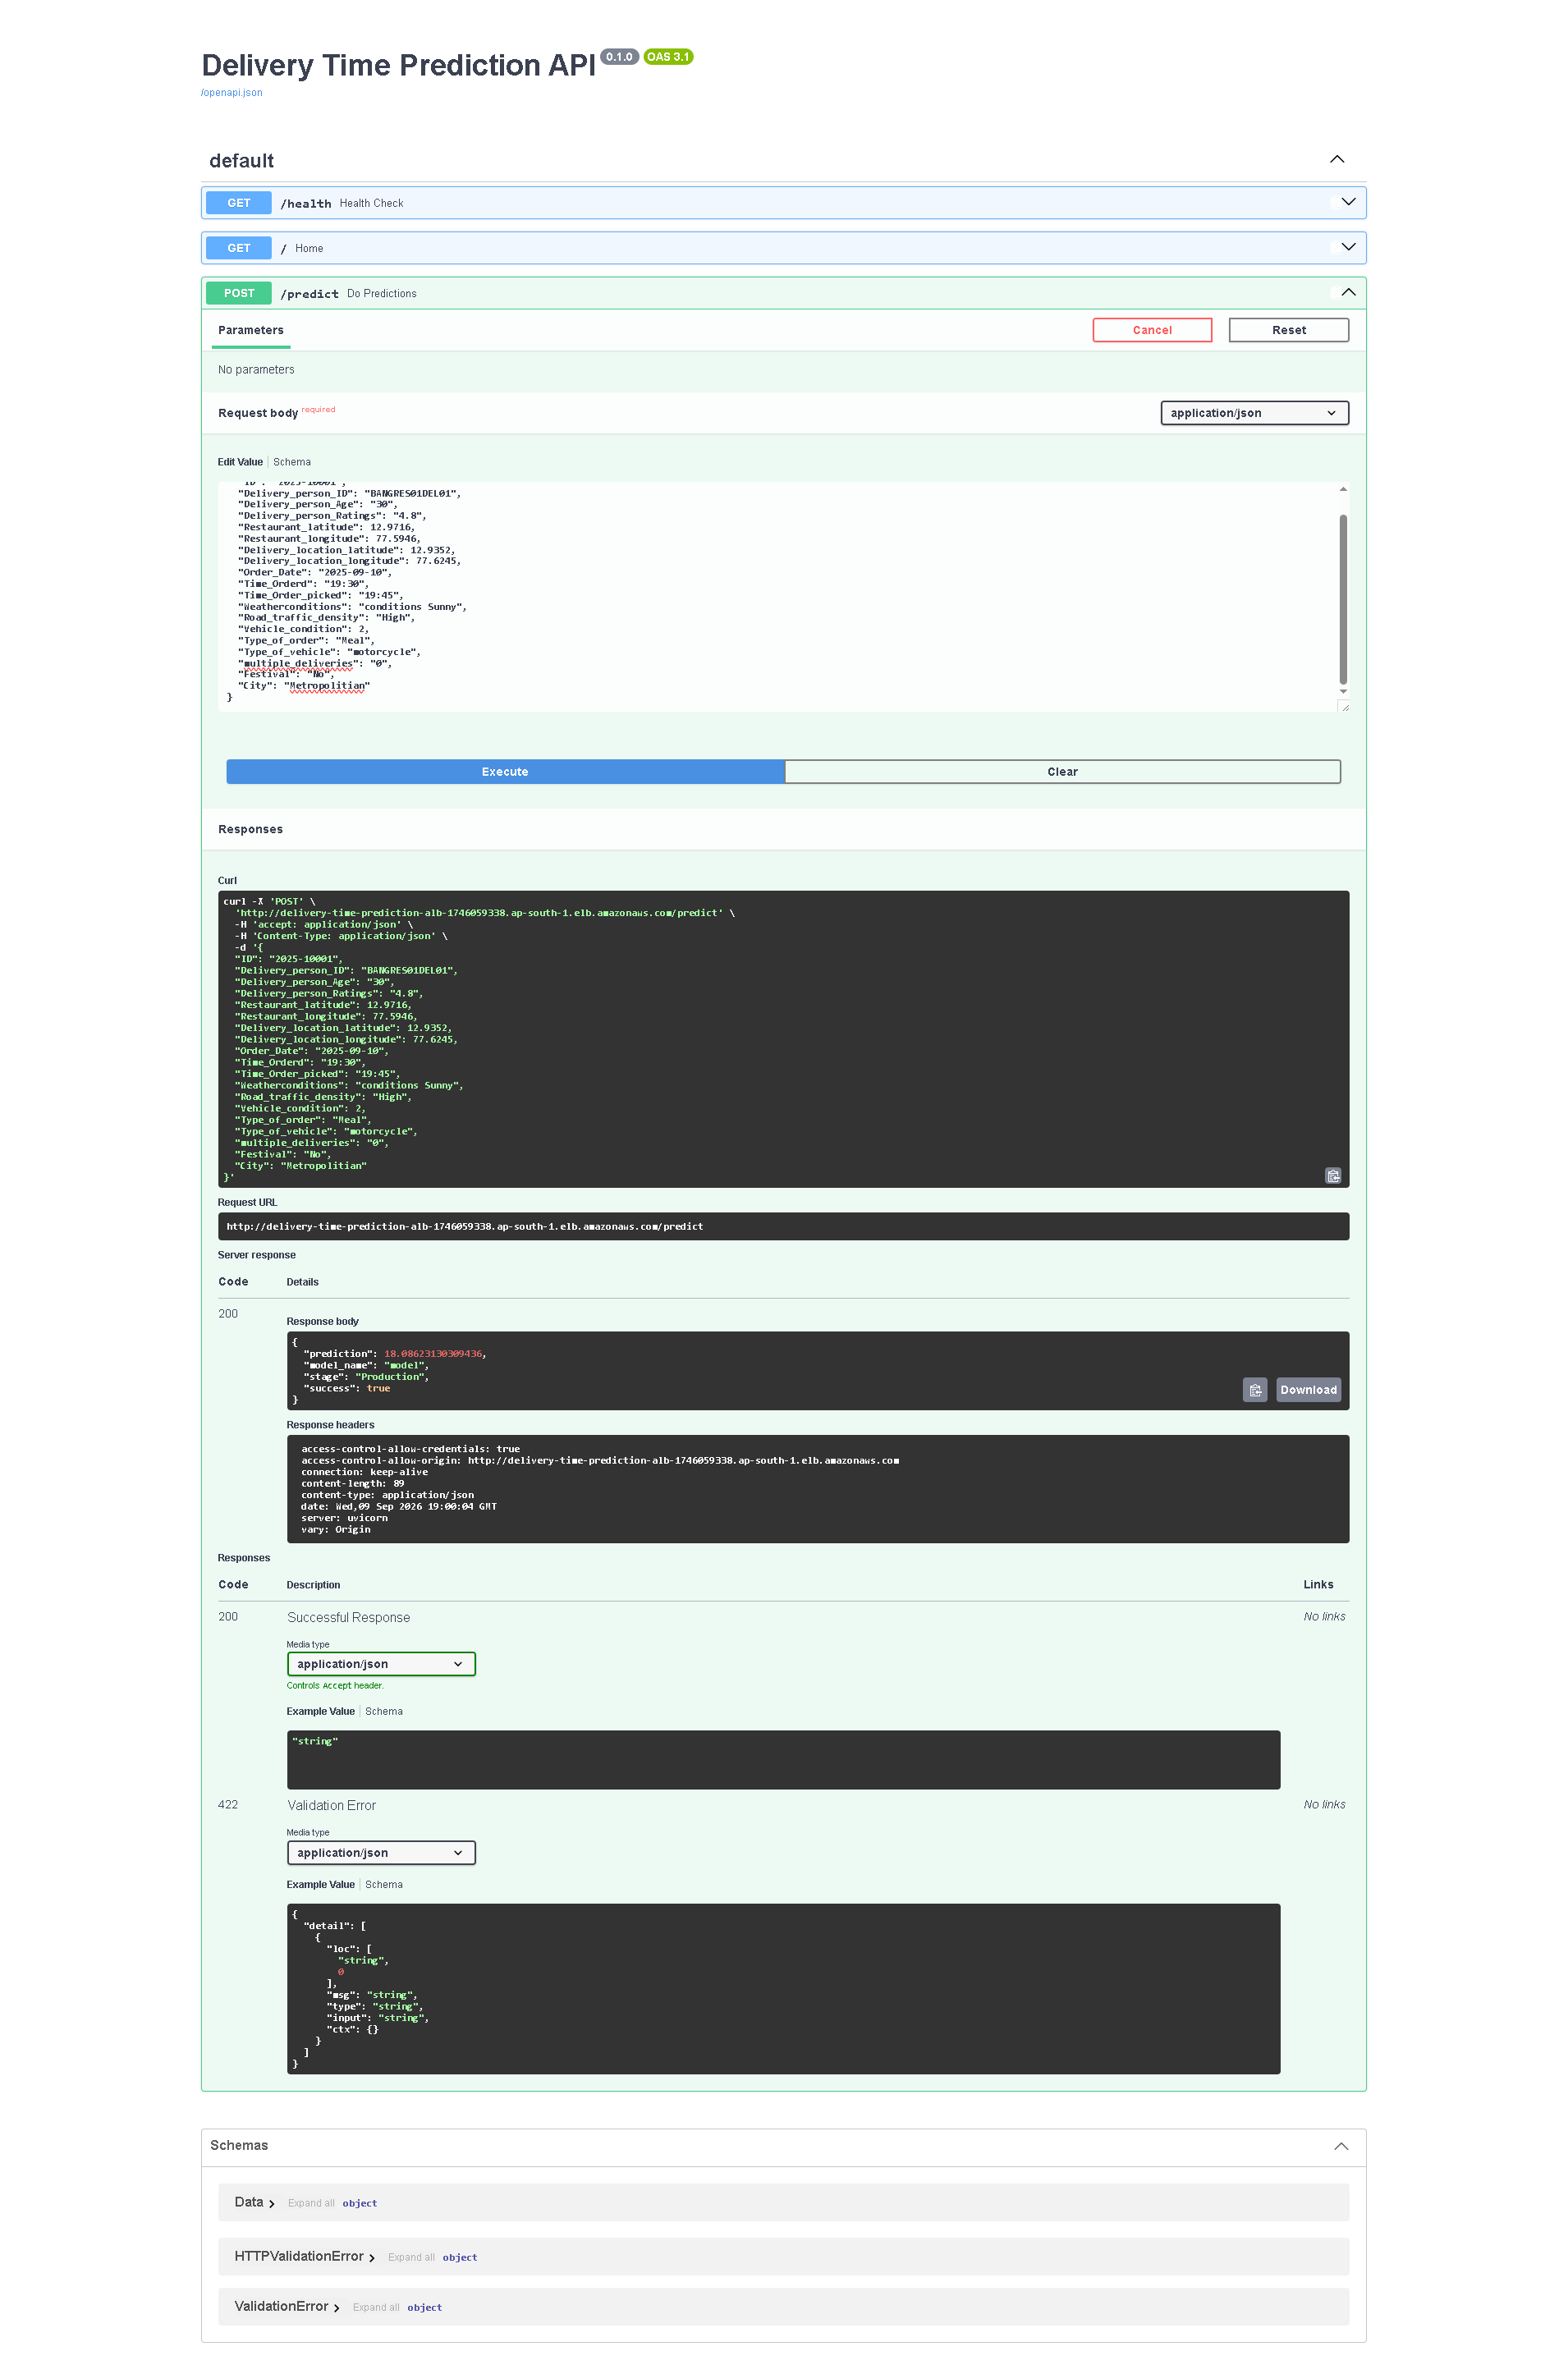


14. Once Testing is completed: If you want ZERO ongoing AWS charges
- For a project/demo that you won't use for a while, the biggest things to consider are:

| Resource        | Action                                               |
| --------------- | ---------------------------------------------------- |
| EC2             | Stop/terminate                                       |
| ASG             | Set desired/min = 0                                  |
| ALB             | **Delete** if not needed                             |
| Target Groups   | Delete after ALB                                     |
| CodeDeploy      | Keep — essentially no meaningful idle compute charge |
| Launch Template | Keep                                                 |
| ECR             | Keep images, or delete old images                    |
| S3              | Keep deployment artifact                             |
| EBS             | Keep if you want to preserve the EC2                 |
| Elastic IP      | Release if you have an allocated unused EIP          |


### 2. ECS

- ECS deployment is pretty simple then above deployment
- Until **pushing docker image to ECR** in cicd - remains same in every deployment
- Once docker image is in ECR, then we can deploy on different deployment options based on requirements

1. Create ECS cluster (the infrastructure where all docker containers will run)
    - name: swiggy-delivery-cluster
    - infra: fargate only
    - add cloudwatch monitoring
    - create

2. Create task definition
    - task definition family: swiggy-delivery-task
    - launch type - aws fargate
    - os: linux
    - 1 cpu & 2gb
    - task role - ecsTaskExecutionrole
    - container name - delivery-time-prediction-api
    - s3 uri - 739275446561.dkr.ecr.ap-south-1.amazonaws.com/prashant-ecr:latest
    - port 8000
    - add env variable (.env file)
    - create

   
3. Now go back to cluster --> swiggy-delivery-cluster --> create service
    - Task definition family
    - version
    - service name
    - environment --> compute option --> launch type
    - launch type --> farget --> version --> latest
    - deployment config --> replica --> deployment type --> rolling update
    - networking - pulic ip turned on
    - load balancer - application load balancer - create new - swiggy-delivery-loadbalancer - listener port 80
    - target group - swiggy-delivery-targetgroup - port 8000 - path /health
    - create
    - Wait 2–5 minutes & Refresh the ECS cluster page
    - it should say: Services: 1 active / Tasks: 1 running
    - service name will be: swiggy-delivery-task-service-8s95wi76
    - open the service (click) --> navigate to Deployments and tasks
    - Desired: 1 / Running: 1 / Pending: 0
    - check target group - swiggy-delivery-targetgroup - targets
    - it should say: IP: 172.31.x.x / Port: 8000 / Health: healthy
    - test alb: EC2 → Load Balancers → swiggy-delivery-loadbalancer
    - open: http://"ALB-DNS"/health


4. AWS infrastructure is complete, Update CICD code.

      # -----------------------------
      # Deploy to ECS (force new deployment)
      # -----------------------------
      - name: Deploy to Amazon ECS
        if: success()
        run: |
          aws ecs update-service \
            --cluster swiggy-delivery-cluster \
            --service swiggy-delivery-task-service-8s95wi76 \
            --force-new-deployment \
            --region ap-south-1

      # -----------------------------
      # Wait for ECS deployment to stabilize
      # -----------------------------
      - name: Wait for ECS service to stabilize
        if: success()
        run: |
          aws ecs wait services-stable \
            --cluster swiggy-delivery-cluster \
            --services swiggy-delivery-task-service-8s95wi76 \
            --region ap-south-1

### 3. EKS